In [12]:
# ---------------------------------------------------------------------------- #
#                            01 - Xenium QC analysis                           #
# ---------------------------------------------------------------------------- #
## Date: April 2026
## Author: Nathalie Nataren

In [13]:
### Import packages
import anndata as ad
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import squidpy as sq
import matplotlib as mpl
from matplotlib import rc_context
import random
import dask
dask.config.set({"dataframe.query-planning": True})
 
import warnings
warnings.filterwarnings("ignore") 

# Note that BANKSY itself is deterministic, here the seeds affect the umap clusters and leiden partition
seed = 1234
np.random.seed(seed)
random.seed(seed)



In [14]:
# ---------------------------------------------------------------------------- #
#                              LOCAL TESTING BLOCK                             #
# ---------------------------------------------------------------------------- #

## Set the dataset_name and related settings to use during this analysis
dataset_name = "CK_skin_res" # sample name
pc_label = "20" # Label for the number of principal components used for the purpose of filenames
pc_dims = [int(pc_label)] # The number of principal components stored a list for analyses
lambda_label = "0.20" # File name label for Lambda setting, see comment below. 
lambda_list = [float(lambda_label)] # Lambda setting to tune BANKSY clustering, lambda = 0 is non-spatial, 0.2 is for cell typing, 0.8 if for domain segmentation 
res_label = "0.50" # BANKSY clustering resolution label for resolution chosen to produce plots
resolutions = [float(res_label)] # BANSY can take a list of resolutions and perform clustering at each which is saved in the BANKSY dictionary

nbr_weight_decay = "scaled_gaussian" # This parameter dictates how much neighbouring cells impact to the neighbourhood expression calculations. Using scaled gaussian, the 
# close neigbours contribute more and this decays as you move out to cells further away in the neighbourhood window. It is scaled for local cell density so that weighting doesn't change
# across regions if cells are pack more closely or loosely in different regions
coord_keys = ('x', 'y', 'xy') # Keys to specify coordinate indexes in the anndata Object

new_labels = { # These are the cluster labels for cell types
    "0" : "Differentiated_or_Melanocytic melanoma cells (MITF+)_0",
    "1" : "Cycling melanoma cells_1",
    "2" : "Invasive melanoma cells (MITF+)_2",
    "3" : "M2-like Tumour Associated Macrophages (CXCL12+)_3",
    "4" : "Dedifferentiated melanoma (angiogenic_or_hypoxic)_4",
    "5" : "Invasive neural crest-like melanoma cells_5", 
    "6" : "Mesenchymal-like melanoma cells_6",
    "7" : "M2-like Tumour Associated Macrophages (CXCL16)_7",
    "8" : "Vascular endothelial cells_8",
    "9" : "Cancer associated fibroblasts (ECM-remodelling)_9",
    "10" : "Melanocytic Melanoma Cells (MITF+ PKHD1L1+)_10",
    "11" : "Skin epithelial cells_11",
    "12" : "Stromal cells_12"}	


In [15]:

# # --------------------- PARSE ARGUMENTS FROM JSON CONFIG --------------------- #

# # This block of code feeds arguments to this python script from a config files found in /config

# ## Import argparse and json packages to read in variables from the per sample .json config files 
# import argparse
# import json

# parser = argparse.ArgumentParser(prog="used to parse arguments form 00_QC_xenium_spatial.py to run on slurm") # Initialise the parser
# parser.add_argument("--config", type=str, help="Provide a JSON config file for each Xenium sample", required=True) # This defines the flag and tells the script to look for a JSON config
# # in the form of a string config file path
# args = parser.parse_args() # Looks at what is passed throught the terminal (in the slurm script in this case) after --config and stores it 

# with open(args.config) as f: # Opens the file path provided by the user
#     cfg = json.load(f) # Converts the json config into a python dictionary called "cfg"

# ## Set the dataset_name and related settings to use during this analysis by taking the argument values from the "cfg" dictionary read in from the JSON config
# dataset_name = cfg["dataset_name"] # sample name
# pc_label = cfg["pc_label"] # Label for the number of principal components used for the purpose of filenames
# pc_dims = [int(pc_label)] # The number of principal components stored a list for analyses
# lambda_label = cfg["lambda_label"] # File name label for Lambda setting, see comment below. 
# lambda_list = [float(lambda_label)] # Lambda setting to tune BANKSY clustering, lambda = 0 is non-spatial, 0.2 is for cell typing, 0.8 if for domain segmentation 
# res_label = cfg["res_label"] # BANKSY clustering resolution label for resolution chosen to produce plots
# resolutions = [float(res_label)] # BANSY can take a list of resolutions and perform clustering at each which is saved in the BANKSY dictionary
# nbr_weight_decay = cfg["nbr_weight_decay"] # This parameter dictates how much neighbouring cells impact to the neighbourhood expression calculations. Using scaled gaussian, the 
# # close neigbours contribute more and this decays as you move out to cells further away in the neighbourhood window. It is scaled for local cell density so that weighting doesn't change
# # across regions if cells are pack more closely or loosely in different regions

# coord_keys = tuple(cfg["coord_keys"]) # Keys to specify coordinate indexes in the anndata Object
# new_labels = cfg["new_labels"] # These are the cluster labels for cell types

In [16]:
# ---------------------------------------------------------------------------- #
#                                   SET PATHS                                  #
# ---------------------------------------------------------------------------- #
## Set file paths and read in xenium data

## Create a base path
base_dir = "data/xenium"
#base_dir = "/home/nnataren/Documents/PhD/Bioinformatics/Banksy_py_fork/Banksy_py/hpc"

## Create a path to the raw data e.g., unprocessed anndata files, if it does not already exist
raw_path = os.path.join(base_dir, "raw_data")

if not os.path.isdir(raw_path):
    os.makedirs(raw_path)
    print(f"Directory '{raw_path} successfully.")
    
else:
    print(f"Directory '{raw_path} exists.")

## Create path for processed data e.g., the pre-clustered but unfiltered anndata files, if it does not already exist
processed_path = os.path.join(base_dir, "processed", f"{dataset_name}")

if not os.path.isdir(processed_path):
    os.makedirs(processed_path)
    print(f"Directory '{processed_path}' created successfully.")
    
else:
    print(f"Directory '{processed_path}' already exists.")

## Create a path for output data, if it does not already exist
output_path = os.path.join(base_dir, "output", f"{dataset_name}")

if not os.path.isdir(output_path):
    os.makedirs(output_path)
    print(f"Directory '{output_path}' created successfully.")
    
else:
    print(f"Directory '{output_path}' already exists.")

## Create a path for QC results, if it does not already exist
qc_path = os.path.join(base_dir, "output", "QC_testing", f"{dataset_name}")

if not os.path.isdir(qc_path):
    os.makedirs(qc_path)
    print(f"Directory '{qc_path}' created successfully.")
else:
    print(f"Directory '{qc_path}' already exists.")

Directory 'data/xenium/raw_data exists.
Directory 'data/xenium/processed/CK_skin_res' already exists.
Directory 'data/xenium/output/CK_skin_res' already exists.
Directory 'data/xenium/output/QC_testing/CK_skin_res' already exists.


In [17]:
# ---------------------------------------------------------------------------- #
#                                 LOAD ANNDATA                                 #
# ---------------------------------------------------------------------------- #

## Read in the raw AnnData file
#adata = ad.read_h5ad(os.path.join(raw_path, f"{dataset_name}_raw.h5ad"))
#res_str = res_label.rstrip("0")
#res_str = res_str.replace(".", "p" )
#adata = ad.read_h5ad(os.path.join(raw_path, f"adata_spatial_{dataset_name}_{res_str}.h5ad"))
adata = ad.read_h5ad(os.path.join(raw_path, f"{dataset_name}_raw.h5ad"))

## Create 'xy' spatial coordinates from adata.obs
adata.obsm['xy'] = np.vstack([adata.obs['x'], adata.obs['y']]).T

In [18]:
raw_path

'data/xenium/raw_data'

In [19]:
adata.obsm

AxisArrays with keys: spatial, xy

In [20]:
# ---------------------------------------------------------------------------- #
#                            FILTER ZERO COUNT CELLS                           #
# ---------------------------------------------------------------------------- #

## Filter out cells with zero counts
adata = adata[adata.obs['nCount_Xenium'] > 0].copy()

In [21]:
# ---------------------------------------------------------------------------- #
#                            DOWNCAST ANNDATA FILES                            #
# ---------------------------------------------------------------------------- #

### Down cast the anndata files to 32-bit float type to reduce RAM load
## Function to check the float size of the adata.obsm data
from banksy_utils.object_downcasting_utils import check_float, downcast_float
check_float(adata)

## Function to downcast adata.obsm to 32 bit and check that the resulting array is an N-dimensional array
downcast_float(adata, "float32")

# Write the downcast file to AnnData format 
adata.write_h5ad(
    filename = os.path.join(raw_path, f"{dataset_name}_float_32.h5ad"),
    compression="gzip"
    )

# Define float adata file
float_adata = f"{dataset_name}_float_32.h5ad"

xy: shape=(6760, 2), dtype=float64
AnnData object with n_obs × n_vars = 6760 × 304
    obs: 'sample_name', 'x', 'y', 'cell_area', 'nucleus_area', 'transcript_counts', 'total_counts', 'nucleus_count', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'segmentation_method', 'nCount_Xenium', 'nFeature_Xenium'
    var: 'gene_ids', 'feature_types', 'genome'
    obsm: 'spatial', 'xy'
    layers: 'counts' object downcast to float32


In [22]:
# ---------------------------------------------------------------------------- #
#                           LOAD DATA AND COORDINATES                          #
# ---------------------------------------------------------------------------- #

from banksy_utils.load_data import load_adata, display_adata

## To either load data from .h5ad directly or convert raw data to .h5ad format
load_adata_directly = True

## Keys to specify coordinate indexes in the anndata Object
coord_keys = coord_keys

raw_y, raw_x, adata = load_adata(filepath=processed_path, adata_filename=float_adata, load_adata_directly=True, coord_keys=coord_keys)

Looking for data/xenium/processed/CK_skin_res/CK_skin_res_float_32.h5ad
Attemping to read Annadata directly
Anndata file successfully loaded!
Attempting to concatenate spatial x-y under adata.obsm[xy]
Concatenation success!


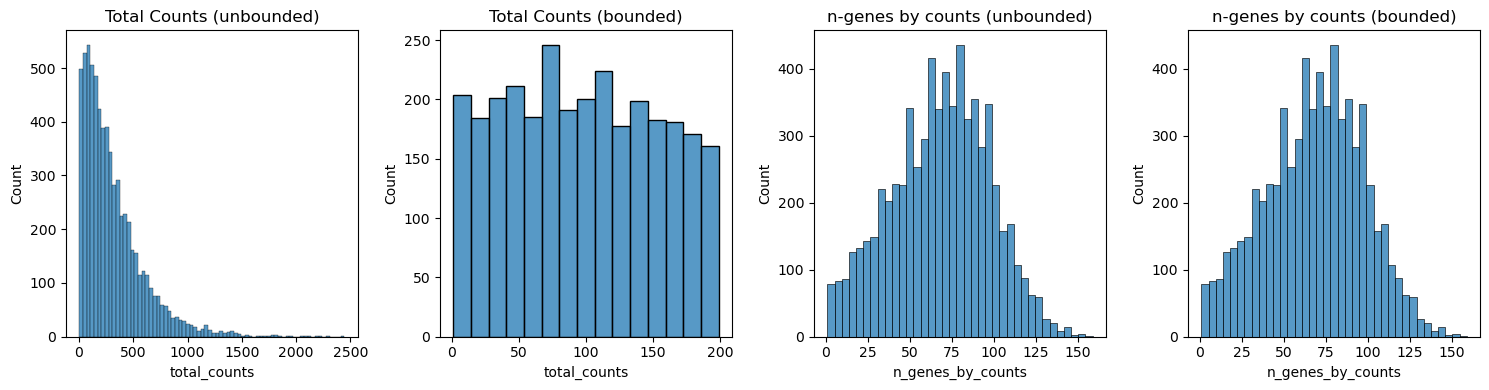

In [23]:
# ---------------------------------------------------------------------------- #
#                          CALCULATE SCANPY QC METRICS                         #
# ---------------------------------------------------------------------------- #

## Calculate some basic scanpy quality metric for plotting
adata.var_names_make_unique() # This ensure all probe names are unique
sc.pp.calculate_qc_metrics(adata, 
                           log1p=True, 
                           inplace=True,
                           percent_top=[10,20]
                           )


from banksy_utils.plot_utils import plot_qc_hist, plot_cell_positions
# bin options for fomratting histograms
# Here, we set 'auto' for 1st figure, 'auto' bins for 2nd figure and so on
hist_bin_options = ['auto', 'auto', 'auto', 'auto']

plot_qc_hist(adata, 
         total_counts_cutoff = 200, # for visualization
         n_genes_high_cutoff = 1000, # for visualization
         n_genes_low_cutoff = 0, # for visualization
         bin_options = hist_bin_options)

plt.savefig(os.path.join(qc_path, f"banksy_counts_and_genes_plot_{dataset_name}.png"), dpi =300, bbox_inches='tight')
plt.show()

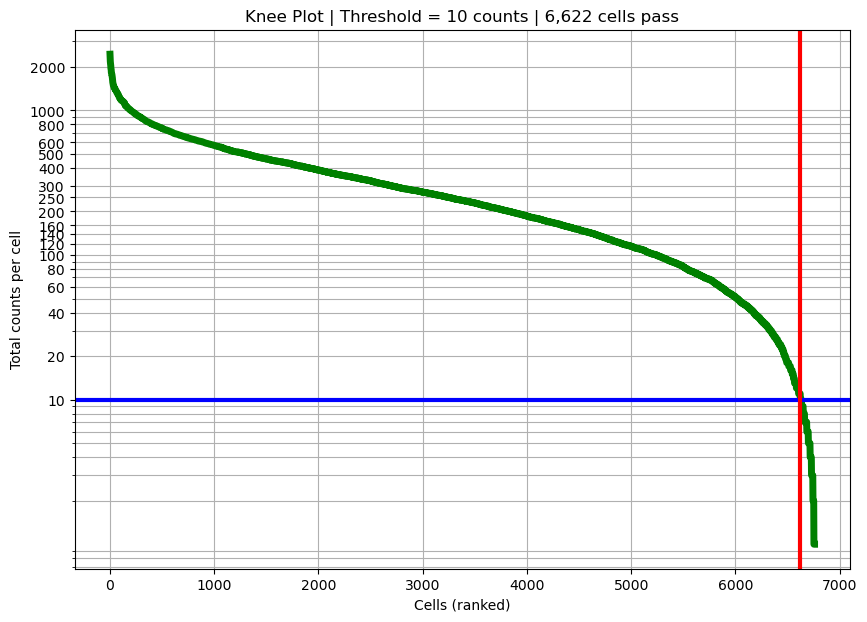

Cells passing threshold of 10 counts: 6,622 / 6,760 (98.0%)


In [24]:
# ---------------------------------------------------------------------------- #
#                FILTER 1 - MINIMUM NUMBER OF TRANSCRIPTS FILTER               #
# ---------------------------------------------------------------------------- #

### Plot knee plot (log10 transcripts per cell)
## Knee plot code adapted from https://pachterlab.github.io/kallistobustools/tutorials/kb_getting_started/python/kb_intro_2_python/

# ------------------- Set the minimum transcript threshold ------------------- #
threshold = 10
knee = np.sort((np.array(adata.X.sum(axis=1))).flatten())[::-1]

## Plot the knee plot
cell_set = np.arange(len(knee))
num_cells = (knee > threshold).sum()
fig, ax = plt.subplots(figsize=(10, 7))

ax.semilogy(knee, linewidth =5, color="g")
ax.axhline(y=threshold, linewidth=3, color="b")
ax.axvline(x=num_cells, linewidth=3, color="r")

ax.set_xlabel("Cells (ranked)")
ax.set_ylabel("Total counts per cell")

ax.set_yticks([10, 20, 40, 60, 80, 100, 120, 140, 160, 200, 250, 300, 400, 500, 600, 800, 1000, 2000])
ax.yaxis.set_major_formatter(mpl.ticker.ScalarFormatter())

plt.grid(True, which="both")
plt.title(f"Knee Plot | Threshold = {threshold} counts | {num_cells:,} cells pass")
plt.savefig(os.path.join(qc_path, f"transcript_knee_plot_{dataset_name}.png"), dpi =300, bbox_inches='tight')
plt.show()

print(f"Cells passing threshold of {threshold} counts: {num_cells:,} / {len(knee):,} ({num_cells/len(knee)*100:.1f}%)")

In [25]:
# ---------------- Apply the minimum transcripts per cell mask --------------- #

## Apply a mask to retrieve cells that don't pass the filter
mask = adata.obs['nCount_Xenium'] <= threshold

# Turn the masked cells into a data frame
mask.to_frame()
mask_cells = mask.reset_index()
mask_cells = mask_cells.rename(columns={"index":"cell_id", "nCount_Xenium" : "min_trans_passed"})

# # Filter for the poor cells and keep these ids for future plotting
# min_trans_filter_failed = mask_cells[mask_cells['min_trans_passed']]

# Put results for the cells passing the threshold into the object directly
adata.obs['min_trans_passed'] = adata.obs['nCount_Xenium'] > threshold #True = passed

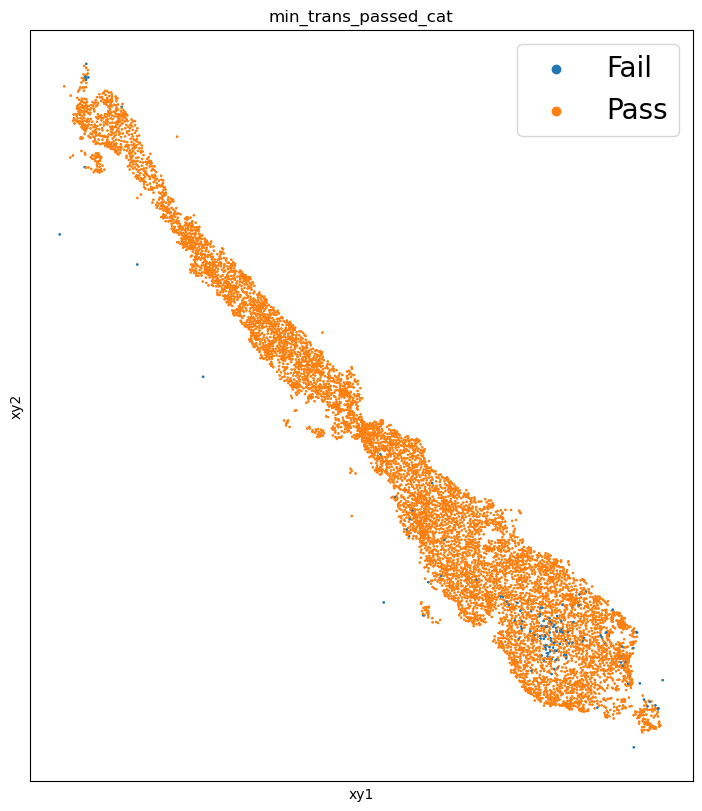

Saving tissue_spatial_scatter_min_counts_threshold_passed_cells_CK_skin_res.png to data/xenium/output/QC_testing/CK_skin_res


In [26]:
# ------------------- Plot location of poor cells on tissue ------------------ #
adata.obs["min_trans_passed_cat"] = adata.obs["min_trans_passed"].map({True: "Pass", False: "Fail"}).astype("category")

with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="min_trans_passed_cat",
        shape=None,
        size=2,
        img=False
    )
    plt.legend(fontsize=20)


# Save the figure
plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_min_counts_threshold_passed_cells_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"Saving tissue_spatial_scatter_min_counts_threshold_passed_cells_{dataset_name}.png to {qc_path}" )                     

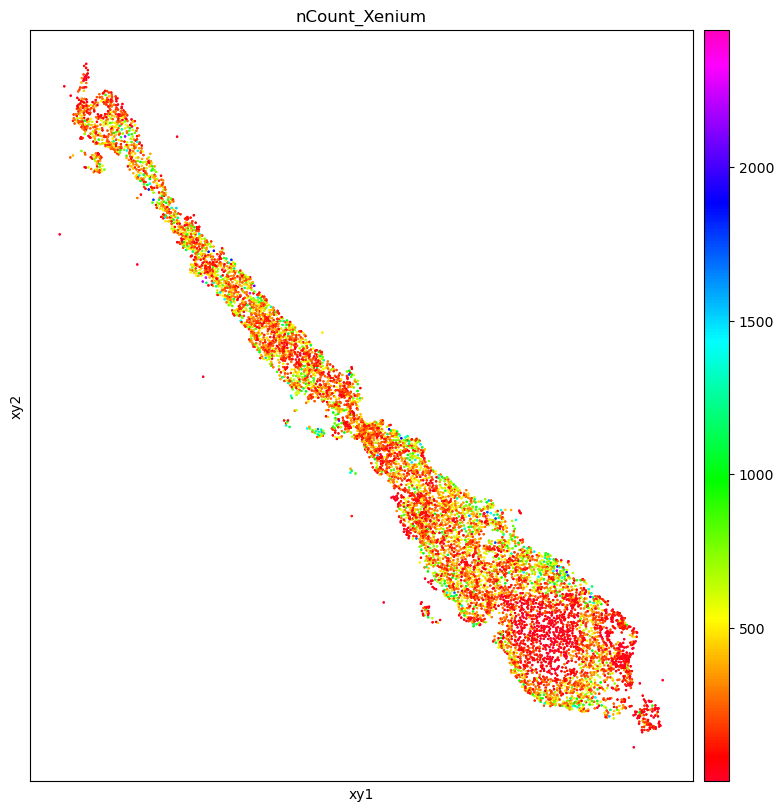

In [27]:
# -------------- Plot of total transripts per cell across sample ------------- #
# gist_stern, dynamic vmax threshold
with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="nCount_Xenium",
        shape=None,
        size=2,
        img=False,
        vmax = adata.obs['nCount_Xenium'].max(),
        cmap="gist_rainbow"
    )

## Save the figure
plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_transcripts_qc_dynamic_range_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 

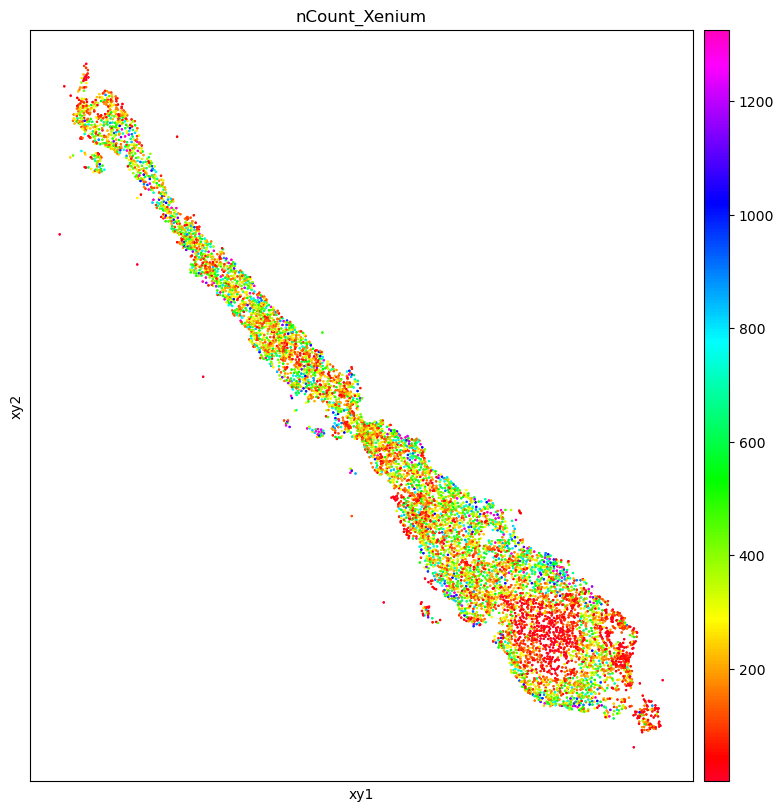

In [28]:
# -------------- Plot of total transripts per cell across sample ------------- #
# vmax set to the 99th percentile of transcript counts
with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="nCount_Xenium",
        shape=None,
        size=2,
        img=False,
        vmax = adata.obs['nCount_Xenium'].quantile(0.99),
        #cmap="gist_stern"
        cmap="gist_rainbow"
        #cmap="rainbow"
    )

plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_transcripts_qc_quantile_99_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 

In [29]:
# ---------------------------------------------------------------------------- #
#           FILTER 2 - MAXIMUM NUMBER OF TRANSCRIPTS FILTER (TOP 2%)           #
# ---------------------------------------------------------------------------- #

# ---- Maximum transcripts per cell mask for cells with top 2% transcripts --- #
qc_metric = 'nCount_Xenium'
quantile = 0.98
qc_metric_label = 'max_trans_98_threshold_passed'

metric = adata.obs[qc_metric]
threshold = np.quantile(metric, quantile)

masked_cells = metric >= threshold
adata.obs[qc_metric_label] = masked_cells

n_marked = adata.obs[qc_metric_label].sum()
n_total = len(adata.obs)
print(
f"Mask created for {qc_metric_label} \n"
f"Mask is True where {qc_metric} >= {threshold:.4g}."
f"{n_marked}/{n_total} cells marked as True.")

Mask created for max_trans_98_threshold_passed 
Mask is True where nCount_Xenium >= 1134.136/6760 cells marked as True.


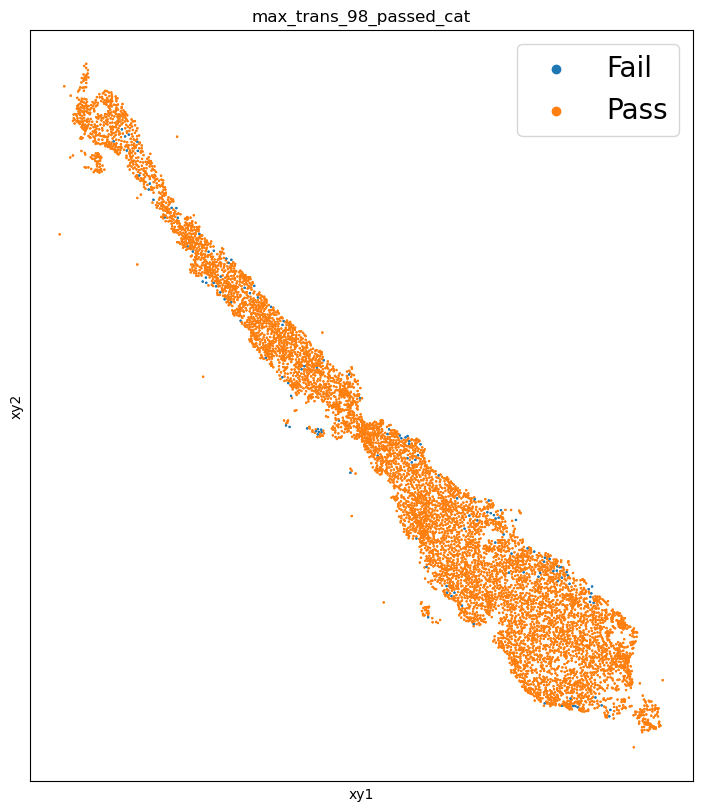

Saving tissue_spatial_scatter_max_counts_threshold_98_passed_cells_CK_skin_res.png to data/xenium/output/QC_testing/CK_skin_res


In [30]:
# ------------------- Plot location of poor cells on tissue ------------------ #
adata.obs["max_trans_98_passed_cat"] = adata.obs["max_trans_98_threshold_passed"].map({True: "Fail", False: "Pass"}).astype("category")

with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="max_trans_98_passed_cat",
        shape=None,
        size=2,
        img=False
    )
    plt.legend(fontsize=20)


# Save the figure
plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_max_counts_threshold_98_passed_cells_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"Saving tissue_spatial_scatter_max_counts_threshold_98_passed_cells_{dataset_name}.png to {qc_path}" )                     

In [31]:
# ---------------------------------------------------------------------------- #
#           FILTER 2 - MAXIMUM NUMBER OF TRANSCRIPTS FILTER (TOP 1%)           #
# ---------------------------------------------------------------------------- #

# ---- Maximum transcripts per cell mask for cells with top 1% transcripts --- #
qc_metric = 'nCount_Xenium'
quantile = 0.99
qc_metric_label = 'max_trans_99_threshold_passed'

metric = adata.obs[qc_metric]
threshold = np.quantile(metric, quantile)

masked_cells = metric >= threshold
adata.obs[qc_metric_label] = masked_cells

n_marked = adata.obs[qc_metric_label].sum()
n_total = len(adata.obs)
print(
f"Mask created for {qc_metric_label} \n"
f"Mask is True where {qc_metric} >= {threshold:.4g}."
f"{n_marked}/{n_total} cells marked as True.")

Mask created for max_trans_99_threshold_passed 
Mask is True where nCount_Xenium >= 1326.68/6760 cells marked as True.


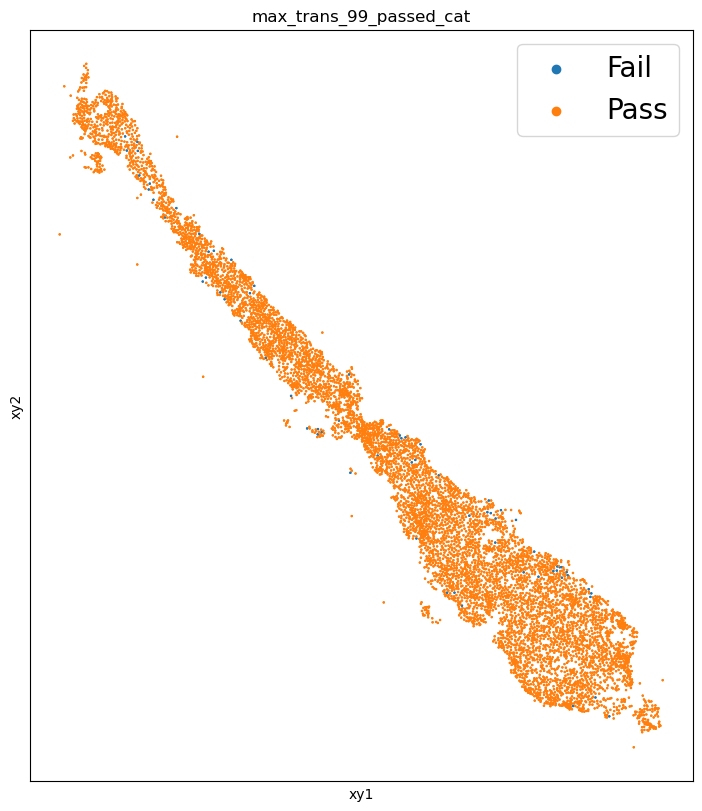

Saving tissue_spatial_scatter_max_counts_threshold_99_passed_cells_CK_skin_res.png to data/xenium/output/QC_testing/CK_skin_res


In [32]:
# ------------------- Plot location of poor cells on tissue ------------------ #
adata.obs["max_trans_99_passed_cat"] = adata.obs["max_trans_99_threshold_passed"].map({True: "Fail", False: "Pass"}).astype("category")

with rc_context({"figure.figsize": (12, 8)}):
    sq.pl.spatial_scatter(
        adata,
        library_id="dataset_name",
        spatial_key="xy",
        color="max_trans_99_passed_cat",
        shape=None,
        size=2,
        img=False
    )
    plt.legend(fontsize=20)


# Save the figure
plt.savefig(
    os.path.join(qc_path, f"tissue_spatial_scatter_max_counts_threshold_99_passed_cells_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )
plt.show() 
print(f"Saving tissue_spatial_scatter_max_counts_threshold_99_passed_cells_{dataset_name}.png to {qc_path}" )      

In [33]:
# ---------------------------------------------------------------------------- #
#                        FILTER 3 - TOP 2% CELLS BY AREA                       #
# ---------------------------------------------------------------------------- #

In [34]:
# ---- Maximum transcripts per cell mask for cells with top 2% transcripts
qc_metric = 'nCount_Xenium'
quantile = 0.98
qc_metric_label = 'max_trans_threshold_passed'

metric = adata.obs[qc_metric]
threshold = np.quantile(metric, quantile)

masked_cells = metric >= threshold
adata.obs[qc_metric_label] = masked_cells

n_marked = adata.obs[qc_metric_label].sum()
n_total = len(adata.obs)
print(
f"Mask created for {qc_metric_label} \n"
f"Mask is True where {qc_metric} >= {threshold:.4g}."
f"{n_marked}/{n_total} cells marked as True.")

Mask created for max_trans_threshold_passed 
Mask is True where nCount_Xenium >= 1134.136/6760 cells marked as True.


In [35]:
# ---------------------------------------------------------------------------- #
#                         EXPORT ADATA.X MATRIX TO .CSV                        #
# ---------------------------------------------------------------------------- #

## Convert the the whole adata.X into a matrix and export to .csv
pd.DataFrame(
    adata.X.toarray(),  # convert sparse matrix to dense
    index=adata.obs_names, 
    columns=adata.var_names
).to_csv(os.path.join(qc_path, f"adata_X_inspection_{dataset_name}.csv"))

obs= adata.obs
obs.to_csv(os.path.join(qc_path, f"obs_{dataset_name}.csv"))

All files saved to: data/xenium/output/QC_testing/CK_skin_res


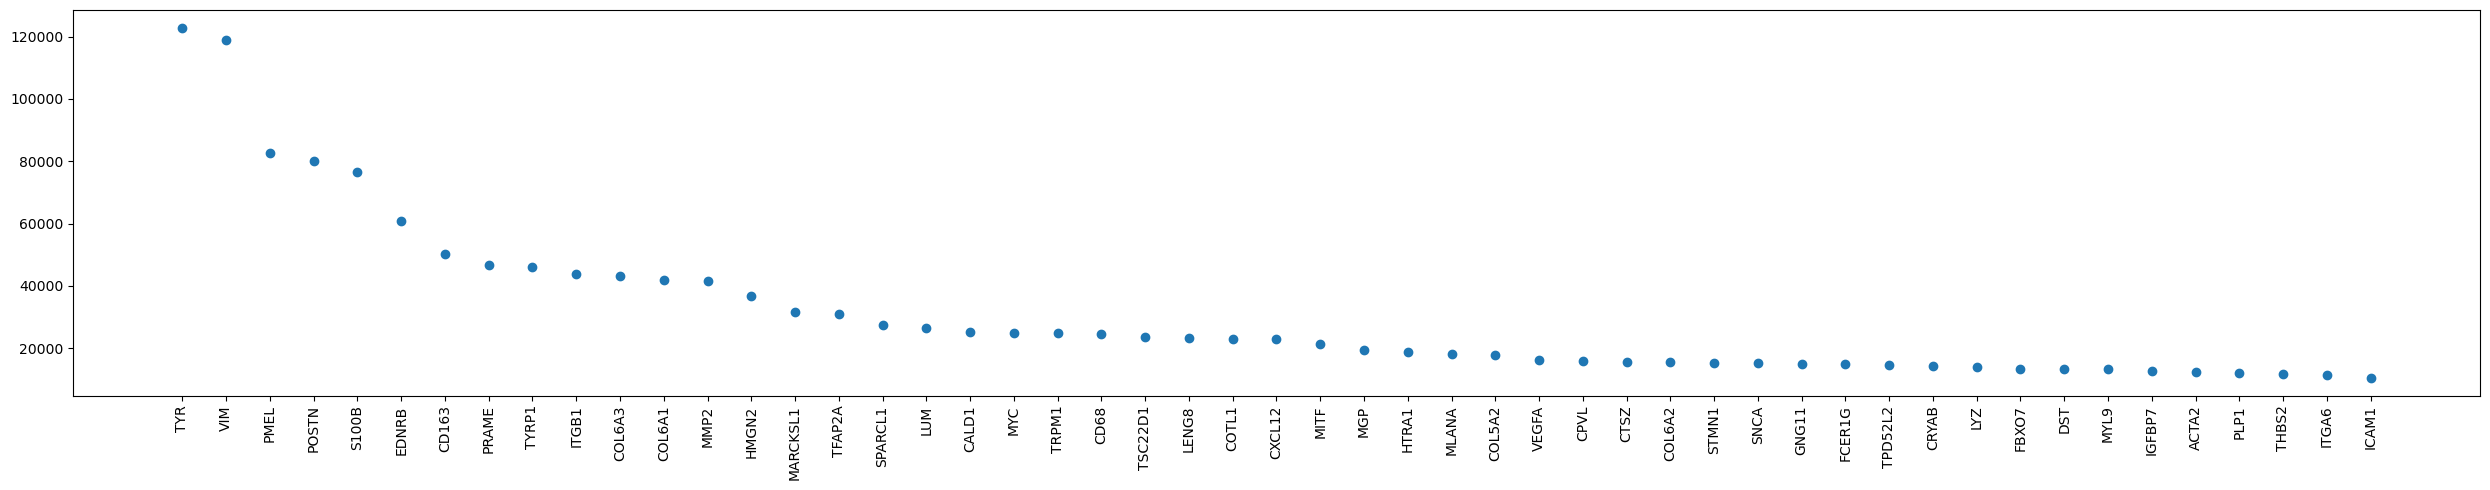

In [36]:
# ---------------------------------------------------------------------------- #
#                             HIGH COUNT GENES PLOT                            #
# ---------------------------------------------------------------------------- #

# ----------- Calculate the sum of a genes counts across all cells ----------- #
## Sort the adata.obs by total_counts to see which genes have exceedingly high counts
obs = adata.obs
obs.sort_values(by=["transcript_counts"], ascending=False)
obs.to_csv(os.path.join(qc_path, f"obs_{dataset_name}.csv"))
print("All files saved to:", qc_path)

# ----------- Calculate the total counts for genes across all cells ---------- #
adata_X = pd.DataFrame(
    adata.X.toarray(),
    index=adata.obs_names,
    columns=adata.var_names
)

gene_total_object = adata_X.sum(axis=0)


top_genes_object = gene_total_object.sort_values(ascending=False).reset_index()
top_genes_object.columns = ['gene', 'total_counts']
top_genes_object.to_csv(os.path.join(qc_path, f"gene_counts_across_all_cells_{dataset_name}_test.csv"))

# --------------------------- Plot the top 50 genes -------------------------- #
top_genes_object = top_genes_object.iloc[0:51]

plt.figure(figsize=(25, 5))
plt.scatter(top_genes_object['gene'], top_genes_object['total_counts'])
plt.xticks(rotation=90)
plt.tight_layout()

plt.savefig(
    os.path.join(qc_path, f"top_50_genes_by_counts_{dataset_name}.png"),
    dpi=300,
    bbox_inches='tight'
    )

In [37]:
## The function below is good for one tailed masking but need to figure out how to handle the lower tail of data e.g., provide it with upper and lower quartiles. 
## Not essential at the moment, will come back to this later!

# def qc_filter_mask(
#     adata,
#     qc_metric: str,
#     qc_metric_label: str,
#     quantile: float) -> None:
#     """
#     Add a boolean mask column to adata.obs for QC metrics to indicate cells that fail 
#     QC, defined as cells at or above the user provided quantile of a QC metrics such as unique transcripts per cell (nCount_Xenium), or cell area

#     Parameters
#     ----------
#     adata : AnnData object
#         The annotated data matrix which is modified in place
#     quantile : float
#         The upper quantile threshold between 0 and 1.
#     qc_metric: str
#         Name of the adata.obs column to which threshold is applied
#     qc_metric_label : str
#         Name assigned to the boolean mask in the adata.obs
#         Cells at or above the quantile threshold are marked True
#     """

#     # Input validation
#     if not 0 <= quantile <= 1:
#         raise ValueError(f"quantile value provided must be between 0 and 1, got {quantile}")

#     if qc_metric not in adata.obs.columns:
#         raise KeyError(f"The '{qc_metric}' is not found in adata.obs."
#         f"Available columns: {list(adata.obs.columns)}")

#     metric = adata.obs[qc_metric]
#     threshold = np.quantile(metric, quantile)
#     masked_cells = metric >= threshold
#     adata.obs[qc_metric_label] = masked_cells

#     n_marked = adata.obs[qc_metric_label].sum()
#     n_total = len(adata.obs)
#     print(
#     f"Mask created for {qc_metric_label}"
#     f"Mask is True where {qc_metric} >= {threshold:.4g}."
#     f"{n_marked}/{n_total} cells marked as True."
#     )

In [38]:
# ---------------------------------------------------------------------------- #
#                      READ IN PRELABELLED ANNDATA OBJECT                      #
# ---------------------------------------------------------------------------- #
file_path =f"{raw_path}/{dataset_name}/{dataset_name}_clustered_spatial_pc{pc_label}_nc{lambda_label}_r{res_label}.h5ad"

print("Exists?", os.path.exists(file_path))

Exists? True


In [ ]:
# -------------------- Read in the processed AnnData file -------------------- # Previous incorrect adata files
import gzip
import pickle

adata_lab = ad.read_h5ad(os.path.join(raw_path, f"{dataset_name}", f"{dataset_name}_clustered_spatial_pc{pc_label}_nc{lambda_label}_r{res_label}.h5ad"))
print(f"Pre-lablled anndata object for {dataset_name} sucessfully read in.")

## Read in the banksy_dict dictionary as a .pkl file
## Use gzip to extract compressed dictionary

dict_name = f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_banksy_dict.pkl.gz"

with gzip.open(os.path.join(raw_path, f"{dataset_name}", dict_name), "rb") as f:
    banksy_dict = pickle.load(f)

## Read in the results_df data frame as a .pkl file
results_name = f"results_df_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.pkl.gz"

with gzip.open(os.path.join(raw_path, f"{dataset_name}", results_name), "rb") as f:
    results_df = pickle.load(f)

In [40]:
raw_path

'data/xenium/raw_data'

In [ ]:
# # ---------------- Read in preclustered, corrected adata files --------------- #

# import gzip
# import pickle

# hpc_path = '/home/nnataren/Documents/PhD/Bioinformatics/Banksy_py_fork/Banksy_py/hpc/processed/'

# res_str = res_label.rstrip('0')
# res_str = str(res_str).replace(".", "p")
# print(res_str)


# adata_lab = ad.read_h5ad(os.path.join(hpc_path, f"{dataset_name}", f"adata_spatial_{dataset_name}_{res_str}.h5ad"))
# print(f"Pre-labelled anndata object for {dataset_name} sucessfully read in.")

# ## Read in the banksy_dict dictionary as a .pkl file
# ## Use gzip to extract compressed dictionary

# #dict_name = f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_banksy_dict.pkl.gz"
# dict_name = "CK_skin_res_pc20_nc0.20_r0.50_0.60_0.70_banksy_dict.pkl.gz"

# with gzip.open(os.path.join(hpc_path, f"{dataset_name}", dict_name), "rb") as f:
#     banksy_dict = pickle.load(f)

# ## Read in the results_df data frame as a .pkl file
# results_name = f"results_df_{dataset_name}_pc{pc_label}_nc{lambda_label}.csv"

# results_df = pd.read_csv(os.path.join(hpc_path, f"{dataset_name}", results_name))
# # print(results_name)

# # with gzip.open(os.path.join(hpc_path, f"{dataset_name}", results_name), "rb") as f:
# #     results_df = pickle.load(f)

0p5
Pre-labelled anndata object for CK_skin_res sucessfully read in.


In [47]:
import scipy.sparse as sp
import numpy as np

## Check if values are integers
if sp.issparse(adata.X):
    values = adata.X.data  # non-zero values only
else:
    values = adata.X.flatten()

print(values[:20])  # look at actual values
print(f"Are all integers: {np.all(values == values.astype(int))}")
print(f"Max value: {values.max()}")
print(f"Min value: {values.min()}")

[1. 1. 1. 1. 1. 1. 4. 1. 2. 8. 1. 1. 8. 1. 1. 1. 1. 5. 3. 1.]
Are all integers: True
Max value: 304.0
Min value: 1.0


In [ ]:
# # ---------------------------------------------------------------------------- #
# #                 CALCULATE PRINCIPAL COMPONENTS FOR CLUSTERING                #
# # ---------------------------------------------------------------------------- #

# import scipy.sparse as sp

# if sp.issparse(adata_lab.X):
#     X = adata_lab.X.toarray()
# else:
#     X = np.array(adata_lab.X) 

# ## Import the noise_equiv_singular_value() function 
# from banksy_utils.pca import plot_singular_values
# import numpy as np

# # Calculate the higher singular value 
# from banksy_utils.pca import noise_equiv_singular_value

# noise_sv, all_permuted_svs = noise_equiv_singular_value(
#     data = X,
#     num_permutations = 50,
#     #average_type = "mean",
#     verbose = True
#     )

# array_shape = X.shape
# print(f"The cell x gene array for '{dataset_name}' is {array_shape}")
# print(f"Noise threshold (mean top singular value of permuted data): {noise_sv:.4f}")

In [ ]:
# # ---------------------------------------------------------------------------- #
# #                                  PERFORM PCA                                 #
# # ---------------------------------------------------------------------------- #
# from sklearn.decomposition import PCA

# pca = PCA(n_components=50).fit(X)

# ## Plot singular values vs noise to determine the optimal number of PC above the noise threshold
# from banksy_utils.pca import plot_singular_values

# plot_singular_values(
#     pca, 
#     noise_highest_sv=noise_sv, 
#     title=f"Singular values vs noise_{dataset_name}",
#     figsize=(20,20),
#     )

# plt.xlabel("Number of principal components", fontsize=20)
# plt.ylabel("Number of singular values", fontsize=20)

# plt.savefig(
#     os.path.join(qc_path, f"singular_values_vs_noise_{dataset_name}.png"),
#     dpi=300,
#     bbox_inches='tight'
#     )
# print(f"Singular values vs noise plot generated for {dataset_name}.")

In [ ]:
# ---------------------------------------------------------------------------- #
#                    DISPLAY PREVIOUSLY GENERATED UMAP PLOTS                   #
# ---------------------------------------------------------------------------- #

## Identify the largest label number and set that to max_num_labels
## extract the seperate spatial and non-spatial results
nonspatial_results = results_df[results_df["decay"] == "nonspatial"]
spatial_results = results_df[results_df["decay"] == "scaled_gaussian"]

nonspatial_labels = nonspatial_results["num_labels"].max()
spatial_labels = spatial_results["num_labels"].max()

def determine_max_num_labels(nonspatial_labels, spatial_labels):
    """ 
    
    This function will determines the maximum number of cluster labels from either the spatial and non-spatial results_df.
    This parameter is required for the BANKSY `plot_results()` function.
    
    Parameters
    ----------

    nonspatial_labels: str
        Maximum number of non-spatial labels from the results_df.
    nonspatial_labels: str
        Maximum number of spatial labels from the results_df.

    """
    if nonspatial_labels > spatial_labels:
        max_num_labels = nonspatial_labels
        print(f"The number of nonspatial labels {nonspatial_labels} is greater than spatial labels {spatial_labels}, so {nonspatial_labels} is assigned to max_num_labels which {max_num_labels}.")

    elif nonspatial_labels < spatial_labels:
        max_num_labels = spatial_labels
        print(f"The number of spatial labels {spatial_labels} is greater than nonspatial labels {nonspatial_labels}, so {spatial_labels} is assigned to max_num_labels which is {max_num_labels}.")

    else: 
        max_num_labels = spatial_labels
        print(f"nonspatial and spatial decay have generated the same number of clusters, so {nonspatial_labels} is assigned to max_num_labels which is {max_num_labels}.")

    return max_num_labels


max_num_labels=determine_max_num_labels(nonspatial_labels, spatial_labels)


In [ ]:
## Plot the tissue spatial cluster plots
from banksy.plot_banksy import plot_results

c_map =  'tab20' # specify color map
weights_graph =  banksy_dict[f"{nbr_weight_decay}"]['weights'][0]

plot_results(
    results_df,
    weights_graph,
    c_map,
    match_labels = False,
    coord_keys = coord_keys,
    max_num_labels  =  max_num_labels, 
    #save_path = os.path.join(file_path, 'tmp_png'),
    save_fig = True, # save the spatial map of all clusters
    save_seperate_fig = True, # save the figure of all clusters plotted seperately
    dataset_name = f"{dataset_name}",
    save_fullfig=True,
    save_path = output_path
)

In [ ]:
# ---------------------------------------------------------------------------- #
#                   GENERATE PLACE HOLDER LABELS FOR CLUSTERS                  #
# ---------------------------------------------------------------------------- #

## Generate place holder labels for clusters
from banksy_utils.cluster_utils import pad_clusters, create_spatial_nonspatial_adata

## Spatial cluster place holders
cluster2annotation_spatial = {}

for i in range(spatial_labels):
    cluster2annotation_spatial[str(i)] = str(i)
print(cluster2annotation_spatial)

## Non-spatial cluster place holders
cluster2annotation_nonspatial = {}

for i in range(nonspatial_labels):
    cluster2annotation_nonspatial[str(i)] = str(i)
print(cluster2annotation_nonspatial)

pad_clusters(cluster2annotation_spatial, list(range(max_num_labels)))

In [ ]:
# ---------------------------------------------------------------------------- #
#                    SAVE ADATA_SPATIAL AND ADATA_NONSPATIAL                   #
# ---------------------------------------------------------------------------- #

## Save annotations in two different anndata objects (adata_spatial and adata_nonspatial)

adata_spatial, adata_nonspatial = create_spatial_nonspatial_adata(results_df,
                                    pc_dims,
                                    lambda_list, 
                                    resolutions,
                                    cluster2annotation_spatial,
                                    cluster2annotation_nonspatial)

In [ ]:
# ---------------------------------------------------------------------------- #
#                    STORECLUSTER LABELS AS A STRING IN .OBS                   #
# ---------------------------------------------------------------------------- #

banksy_dict[f"{nbr_weight_decay}"][0.2]['adata'] #lambda = 0.20
adata_spatial.obs[f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}"]= adata_spatial.obs[f"labels_scaled_gaussian_pc{pc_label}_nc{lambda_label}_r{res_label}"].astype(str)

In [ ]:
# ---------------------------------------------------------------------------- #
#                   MAP THE CELL TYPE LABELS TO THE CLUSTERS                   #
# ---------------------------------------------------------------------------- #

cluster_col = f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}"
adata_spatial.obs[f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann"] = adata_spatial.obs[cluster_col].map(new_labels)

In [ ]:
adata_spatial.obs

In [ ]:


def cluster_violin(
    adata_raw,
    adata_preclustered,
    qc_metric_label : str,
    cluster_key : str,
    qc_path : str
):
    """ 
    
    This function will generate cluster level violin plot of cells for a given qc_metric column that is present in adata.obs. It comapres a raw  adata_raw obejct to preclustered adata objects.
    It will need to be adapted once we are dealing will a single object.
    
    Parameters
    ----------

    adata_raw : str
        adata object prior to filtering.
    adata_preclustered : str
        adata object that has been previously clustered and annotated.
    qc_metric_label : str
        The name of the qc metric column in adata.obs that is to be visualised using the violin plots
    cluster_key : str
        The name of the cluster column in adata.obs such as "banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann"
    qc_path : str
        The path to the qc directory for saving plots.

    """
    adata_preclustered.obs[qc_metric_label] = adata_raw.obs[qc_metric_label]

    ## Transfer the minimum threshold category labels from the adata.obs to the adata_spatial.obs
    adata_preclustered.obs[f"{qc_metric_label}_cat"] = adata.obs[qc_metric_label]

    obs = adata_preclustered.obs

    plt.figure(figsize=(8, 6))
    sns.violinplot(data=obs, y=obs["nCount_Xenium"],  x=obs[cluster_key], log_scale=10, color="lightblue")

    sns.stripplot(data=obs, y=obs["nCount_Xenium"], x=obs[cluster_key], hue =obs[qc_metric_label], size=4)

    plt.xlabel("Cluster", fontsize=15)
    plt.ylabel("Total transcript counts per cell (log10)", fontsize=15)
    plt.xticks(rotation=45, fontsize=12, ha='right', va='top')


    plt.savefig(
        os.path.join(qc_path, f"{qc_metric_label}_per_cluster_violin_plot_{dataset_name}.png"),
        dpi=300,
        bbox_inches='tight'
        )
    print(f"Figure save as '{qc_metric_label}_per_cluster_violin_plot_{dataset_name}.png' in{qc_path}")

In [ ]:
adata.obs

In [ ]:
# ---------------------------------------------------------------------------- #
#    CLUSTER LEVEL VIOLIN PLOTS OF MINIMUM TRANSCRIPT COUNT THRESHOLD CELLS    #
# ---------------------------------------------------------------------------- #
cluster_violin(
    adata_raw = adata,
    adata_preclustered = adata_spatial,
    qc_metric_label = 'min_trans_passed_cat',
    cluster_key = f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
    qc_path = qc_path
)

In [ ]:
# ---------------------------------------------------------------------------- #
#    CLUSTER LEVEL VIOLIN PLOTS OF MAXIMUM TRANSCRIPT COUNT THRESHOLD CELLS    #
# ---------------------------------------------------------------------------- #
cluster_violin(
    adata_raw = adata,
    adata_preclustered = adata_spatial,
    qc_metric_label = 'max_trans_98_passed_cat',
    cluster_key = f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
    qc_path = qc_path
)

In [ ]:
# ---------------------------------------------------------------------------- #
#    CLUSTER LEVEL VIOLIN PLOTS OF MAXIMUM TRANSCRIPT COUNT THRESHOLD CELLS    #
# ---------------------------------------------------------------------------- #
cluster_violin(
    adata_raw = adata,
    adata_preclustered = adata_spatial,
    qc_metric_label = 'max_trans_99_passed_cat',
    cluster_key = f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
    qc_path = qc_path
)

In [ ]:
# ---------------------------------------------------------------------------- #
#                        TOP EXPRESSED GENES PER CLUSTER                       #
# ---------------------------------------------------------------------------- #
### Spatial clustering results

import scanpy as sc

## Rank genes and identify cluster gene markers
sc.tl.rank_genes_groups(
    adata_spatial,
    groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}",
    method='wilcoxon',
    key_added=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_markers"
)

In [ ]:
adata_spatial.uns['banksy_cluster_pc35_nc0.20_r0.50_markers_raw'].keys()

In [ ]:
key = f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r0.50_markers"

print(list(adata_spatial.uns[key].keys()))
# ['params', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges']

In [ ]:
## Using the filter_ranked_genes_by_type to create a key for 
## A key can be generate for the nbr_0 results, which represent markers of neighbour cells not for annotation
## and a key can be generated for nbr_1, where these markers being represents cells that are in a ring interface around given cell
from banksy_utils.annotation_utils import filter_ranked_genes_by_type

key_filtered = filter_ranked_genes_by_type(
    adata_spatial,
    key=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_markers",
    top_n=500,
    gene_type = "raw",
    new_key_suffix="_raw",
)

In [ ]:
print("adata_spatial.raw is None:", adata_spatial.raw is None)
print("adata_spatial.X shape:", adata_spatial.X.shape)

# Sample some values
X = adata_spatial.X
sample = X[:5, :5].toarray() if hasattr(X, "toarray") else X[:5, :5]
print("\nadata_spatial.X sample (5x5):")
print(sample)
print(f"\nX min: {X.min():.3f}, max: {X.max():.3f}, has negatives: {(X < 0).any()}")

In [ ]:
adata.X  # log-normalised after sc.pp.log1p
adata.layers["counts"]  # raw counts

In [ ]:
# Plot the gene markers for each cluster
sc.pl.rank_genes_groups(
    adata_spatial, 
    key=key_filtered,
    method='wilcoxon',
    n_genes=20, 
    fontsize=15,
    save= f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_spatial_top_gene_raw.png")

In [ ]:
# Plot the gene markers for each cluster
sc.pl.rank_genes_groups(
    adata_spatial, 
    key=key_filtered,
    method='wilcoxon',
    n_genes=20, 
    fontsize=15,
    save= f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_spatial_top_gene_raw.png")

In [ ]:
## Total counts across unlabeled clustered
sc.pl.violin(
    adata_spatial, 
    "total_counts", 
    groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}", 
    save= f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
    )

In [ ]:
# ---------------------------------------------------------------------------- #
#                                CLUSTER HEATMAP                               #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = output_path

## Generate heat map for top markers per cluster
sc.tl.dendrogram(
    adata_spatial,
    groupby=f'banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_raw',
    key_added=f'banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_raw'
)

## Determine vmin and vmax dynamically based on gene expression
expr_values = adata_spatial.X
vmax_dynamic = np.percentile(expr_values[expr_values > 0], 99)
vmin_dynamic = np.percentile(expr_values, 1)

sc.pl.rank_genes_groups_heatmap(
    adata_spatial, 
    key=f'banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_markers_raw',
    #key= 'raw_test',
    n_genes=5,
    cmap = "plasma",
    vmin=vmin_dynamic,
    vmax=vmax_dynamic,
    show_gene_labels = True,
    save = f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_raw_markers.png",
    figsize=(20, 15)
)

In [ ]:
# ---------------------------------------------------------------------------- #
#                  GENERATE DENDROGRAM AND CORRELATION MATRIX                  #
# ---------------------------------------------------------------------------- #
groupby_key = f'banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann'

sc.tl.dendrogram(adata_spatial, groupby=groupby_key)

sc.pl.dendrogram(
    adata_spatial,
    groupby=groupby_key,
    save=f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
)

sc.pl.correlation_matrix(
    adata_spatial,
    groupby = groupby_key,
    save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_cluster_correlation_plot.png",
    figsize=(5, 3.5)
)

In [ ]:
# ---------------------------------------------------------------------------- #
#                            EXPORT CLUSTER MARKERS                            #
# ---------------------------------------------------------------------------- #
### Export the top 20 clusters in wide format to .csv

from banksy_utils.annotation_utils import export_clusters_wide

key= f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_markers_raw"

export_clusters_wide(
    adata= adata_spatial,
    key= key,
    gene_type= "raw",
    top_n= 20,
    dataset_name= dataset_name,
    file_path= processed_path
)

In [ ]:
# ### Export the top 20 clusters in long format with scores to .csv

from banksy_utils.annotation_utils import export_cluster_markers

export_cluster_markers(
    adata = adata_spatial,
    key = key,
    top_n = 20,
    dataset_name = dataset_name,
    file_path = processed_path
)

In [ ]:
# ---------------------------------------------------------------------------- #
#                       ADD CELL TYPE INFO TO TOP MARKERS                      #
# ---------------------------------------------------------------------------- #

## Read in the exported cluster markers generated with "export_clusters_wide()"
## and merge with the cell type annotation master document
n_genes_label =  20 # Set this to the number of genes that were exorted as top markers for each cluster
top_markers = pd.read_csv(f"{processed_path}/cluster_top_{n_genes_label}_genes_with_scores_{dataset_name}_{key}.csv", index_col=0) #index_col = 0 prevents insertion of an unnamed col
top_markers = top_markers.sort_values(by='cluster', ascending=False)
#print(top_markers)

## Read in the master annotation file which contains all the curated cell type labels for each marker gene
#master_markers_file = pd.read_csv(f"{raw_path}/xenium_gene_list_annotation_master.csv")
master_markers_file = pd.read_csv(f"{raw_path}/xenium_gene_list_annotation_master_v1_March_2026_Tier1.csv")

## Create a data frame of the genes and their corresponding primary and secondary cell type annotations 
cell_annotations = master_markers_file[["Gene", "primary_annotation", "secondary_annotation"]]
#cell_annotations = cell_annotations.sort_index()

# ## Merge the top marker results and the cell type annotations
# merged_markers = (
#     pd.merge(
#         #top_markers.reset_index(),
#         top_markers.sort_values(by='cluster', ascending=False),
#         cell_annotations, 
#         left_on="gene", 
#         right_on="Gene", 
#         how="left", 
#         sort="False",
#         #validate="m:1"
#     )
#     #.set_index("index")
#     #.loc[top_markers.index]
# )

merged_markers = top_markers.reset_index().merge(
    cell_annotations,
    left_on="gene",
    right_on="Gene",
    how='left'
)
merged_markers['cluster'] = merged_markers['cluster'].astype(int)
merged_markers = merged_markers.sort_values('cluster', ascending=True).reset_index(drop=True)
merged_markers = merged_markers.drop("Gene", axis=1)
print(merged_markers)

## Export the cell type annotated top markers to .csv to use in manual annotation and ChatGPT annotation
merged_markers.to_csv(f"{processed_path}/cell_type_cluster_top_{n_genes_label}_genes_{dataset_name}_{key}.csv")

In [ ]:
#  ---------------------------------------------------------------------------- #
#                        ADD CELL TYPE INFO TO TOP MARKERS                      #
#  ---------------------------------------------------------------------------- #
## The top 20 gene markers for each cluster are assessed for cell cluster annotation
# cluster_col = f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}"
# adata_spatial.obs[f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann"] = adata_spatial.obs["cell type"].map(new_labels)

In [ ]:
# ---------------------------------------------------------------------------- #
#                        STORE THE UMAP RESULTS IN .OBSM                       #
# ---------------------------------------------------------------------------- #
adata_spatial.obsm['X_umap'] = banksy_dict['scaled_gaussian'][0.2]['adata'].obsm[f"reduced_pc_{pc_label}_umap"]

In [ ]:
# ---------------------------------------------------------------------------- #
#                                ANNOTATED UMAP                                #
# ---------------------------------------------------------------------------- #

### Cluster Annotated UMAP
## Plot the umap with bulk labels
import scanpy as sc
from matplotlib.pyplot import rc_context

color_vars = [
f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann"
]

with rc_context({"figure.figsize": (3,3)}):
    sc.pl.umap(
        adata_spatial, 
        color=color_vars, 
        s=50, 
        frameon=True, 
        vmax="p99",
        add_outline=True,
        legend_fontsize=10,
        title=f"{dataset_name} clusters",
        save = f"_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
        )

In [ ]:
# ---------------------------------------------------------------------------- #
#            UMAP WITH BULK LABELS AND UMAP WITH MIN TRANS THRESHOLD           #
# ---------------------------------------------------------------------------- #

# ----------------------- PLOT UMAP THRESHOLD FUNCTION ----------------------- #


def plot_umap_threshold(
    data,
    qc_metric,
    cluster_key,
    dataset_name,
    qc_path,
    fig_size=(20, 10),
    dpi=300,
    show=True,
    **kwargs
    ):
    """ 
    
    This function will plot a labelled cluster UMAP alongside a UMAP of quality control metrics for comparison.
    QC metrics stored in the adata.obs slot can be viewed on the UMAP using this function.
    
    Parameters
    ----------

    data: AnnData
        Annotated data object with UMAP already computed
    qc_metric : str
        A column name in the `adata.obs` to plot onto the UMAP.
    cluster_key : str
        The cluster key which denotes which resolution, lambda and pc clustering was performed at
    qc_path : str
        Path to QC results folder
    fig_size
        Figure size dimentions
    show : boolean
        To show or not show the figure
   
    """
    print(f"cluster_key={cluster_key!r}, qc_metric={qc_metric!r}")
    print(f"cluster dtype: {data.obs[cluster_key].dtype}")
    print(f"qc dtype: {data.obs[qc_metric].dtype}")
    
    # UMAP plot for labellled clusters
    fig, axes = plt.subplots(1, 2, figsize=fig_size)

    sc.pl.umap(
        data, 
        color=cluster_key, 
        s=5, 
        frameon=True, 
        add_outline=True,
        legend_fontsize=10,
        title=f"{dataset_name} {cluster_key}",
        ax=axes[0],
        show=False,
        **kwargs
        )

    # UMAP plot for QC metric
    sc.pl.umap(
        data, 
        color=qc_metric, 
        s=5, 
        frameon=True, 
        add_outline=True,
        legend_fontsize=10,
        title=f"{dataset_name} {qc_metric}",
        ax=axes[1],
        show=False,
        **kwargs
        )

    plt.tight_layout()
    out_path = os.path.join(qc_path, f"umap_{dataset_name}_{qc_metric}.png")

    plt.savefig(out_path, dpi=dpi, bbox_inches='tight')

    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig

In [ ]:
# ------------ Cells masked for minimum transcript counts on UMAP ------------ #
min_transcript_fig= plot_umap_threshold(
    data=adata_spatial,
    qc_metric="min_trans_passed_cat",
    cluster_key= f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
    dataset_name=dataset_name,
    qc_path=qc_path,
    fig_size=(20, 10),
    dpi=300,
    show=True
    )

In [ ]:
# ----------------- Top 2% cells by transcript counts on UMAP ---------------- #
max_transcript_fig= plot_umap_threshold(
    data=adata_spatial,
    qc_metric="max_trans_passed_cat",
    cluster_key= f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
    dataset_name=dataset_name,
    qc_path=qc_path,
    fig_size=(20, 10),
    dpi=300,
    show=True
    )

In [ ]:
# ---------------------------------------------------------------------------- #
#                              SET PATHS FOR PLOTS                             #
# ---------------------------------------------------------------------------- #

## Create a path for gene of interest UMAP plots
umap_path = os.path.join(base_dir,f"output/{dataset_name}/umap/")

if not os.path.isdir(umap_path):
    os.makedirs(umap_path)
    print(f"Directory '{umap_path}' created successfully.")
    
else:
    print(f"Directory '{umap_path}' already exists.")


## Create a path for gene of interest violin plots
violin_path = os.path.join(base_dir,f"output/{dataset_name}/violin/")

if not os.path.isdir(violin_path):
    os.makedirs(violin_path)
    print(f"Directory '{violin_path}' created successfully.")
    
else:
    print(f"Directory '{violin_path}' already exists.")

## Create a path for gene of interest dot plots
dotplot_path = os.path.join(base_dir,f"output/{dataset_name}/dotplot/")

if not os.path.isdir(dotplot_path):
    os.makedirs(dotplot_path)
    print(f"Directory '{dotplot_path}' created successfully.")
    
else:
    print(f"Directory '{dotplot_path}' already exists.")

## Create a path for gene of interest UMAP plots
neighbour_path = os.path.join(base_dir,f"output/{dataset_name}/neighbourhood_centrality_co-occurence/")

if not os.path.isdir(neighbour_path):
    os.makedirs(neighbour_path)
    print(f"Directory '{neighbour_path}' created successfully.")
    
else:
    print(f"Directory '{neighbour_path}' already exists.")


## Create a path for gene of interest spatial scatter plots
spatial_scatter_path = os.path.join(base_dir,f"output/{dataset_name}/spatial_scatter/")

if not os.path.isdir(spatial_scatter_path):
    os.makedirs(spatial_scatter_path)
    print(f"Directory '{spatial_scatter_path}' created successfully.")
    
else:
    print(f"Directory '{spatial_scatter_path}' already exists.")

In [ ]:
# ---------------------------------------------------------------------------- #
#                        GENE OF INTEREST UMAP FUNCTION                        #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = umap_path
def plot_goi_umaps (
    genes: list,
    adata,
    sample_name: str,
    s: int = 20,
    **kwargs #additional sc.pl.umap arguments such as ncols
):

    """ 
    
    This function will plot a UMAP coloured by the expression of a gene(s) of interest.
    
    Parameters
    ----------
    genes : list
        A list of genes to plot
    adata : AnnDataobject
        adata object with embeddings
    sample_name : str
        Sample name for the plot title
    s : int
        This will change the dot size for each cell on the UMAP
    **kwargs
        This will take other general arguments for the sc.pl.umap() function that have not been listed explicitly as and argument of this function.
       
    """

    title_list = []

    for i in genes:
        title = f"{i} expression in {sample_name}"
        title_list.append(title)
        gene_str = "_".join(genes)

    with rc_context({"figure.figsize": (8,5)}):
        sc.pl.umap(
            adata, 
            color=genes, 
            s=20, 
            frameon=True, 
            vmax="p99",
            add_outline=True,
            legend_fontsize=9,
            title=title_list,
            save = f"_{sample_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_{gene_str}_response_genes.png",
            **kwargs
            )

In [ ]:
## DSG2 UMAP
plot_goi_umaps(genes=["DSG2", "TPD52L2"],
adata=adata_spatial,
sample_name= dataset_name,
s=20, )

In [ ]:
## SERPINE1 UMAP
plot_goi_umaps(genes=["SERPINE1"],
adata=adata_spatial,
sample_name= dataset_name,
s=20, )

In [ ]:
### DKK1

plot_goi_umaps(genes=["DKK1"],
adata=adata_spatial,
sample_name= dataset_name,
s=20, )

In [ ]:
### T cell markers

plot_goi_umaps(genes=["FOXP3", "GZMB"],
adata=adata_spatial,
sample_name= dataset_name,
s=20, )

In [ ]:
### Integrin genes

plot_goi_umaps(genes=[
"ITGAE", 
"ITGA1", 
"ITGA4",
"ITGA5"],
adata=adata_spatial,
sample_name= dataset_name,
s=20,
ncols=2
)

In [ ]:
# ### TPD52 family

plot_goi_umaps(genes=[
"TPD52", 
"TPD52L1", 
"TPD52L2"
],
adata=adata_spatial,
sample_name= dataset_name,
s=20,
ncols=2
)

In [ ]:
#### Selectins

plot_goi_umaps(genes=[
"SELE", 
"SELL", 
"SELP"
],
adata=adata_spatial,
sample_name= dataset_name,
s=20,
ncols=2
)

In [ ]:
# ### Fucosyltransferase genes

plot_goi_umaps(genes=[
"FUT6", 
"FUT7"
],
adata=adata_spatial,
sample_name= dataset_name,
s=20
)

In [ ]:
# ### Adhesion molecules

plot_goi_umaps(genes=[
"VCAM1", 
"ICAM1"
],
adata=adata_spatial,
sample_name= dataset_name,
s=20
)

In [ ]:
# ### ICI response genes

plot_goi_umaps(genes=[
"PDCD1", 
"CD274", 
"CTLA4"
],
adata=adata_spatial,
sample_name= dataset_name,
s=20
)

In [ ]:
# ---------------------------------------------------------------------------- #
#                         GENE EXPRESSION VIOLIN PLOTS                         #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = violin_path

with rc_context({"figure.figsize": (10, 8)}):
    ax= sc.pl.violin(
        adata_spatial,
        ["nFeature_Xenium"],
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        stripplot=False,  # remove the internal dots
        inner="box",  # adds a boxplot inside violins
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_gene_count_per_cluster_violin_plot.png"
    )

In [ ]:
#### DSG2

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata_spatial, 
        keys = [
            "DSG2"
            ], 
        #groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("DSG2 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DSG2_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)

In [ ]:
#### SERPINE1

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata_spatial, 
        keys = [
            "SERPINE1"
            ], 
        #groupby=f"banksy_cluster_pc{pc_label_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("SERPINE1 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_SERPINE1_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)

In [ ]:
#### DKK1

with rc_context({"figure.figsize": (10,8)}):
   ax = sc.pl.violin(
        adata_spatial, 
        keys = [
            "DKK1"
            ], 
        #groupby=f"banksy_cluster_pc{pc_label_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )
ax.set_yscale('log')
ax.set_xlabel('Cell type', fontsize=12)
ax.set_ylabel("DKK1 expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_DKK1_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)

In [ ]:
#### T cell markers

with rc_context({"figure.figsize": (10,8)}):
   axes = sc.pl.violin(
        adata_spatial, 
        keys = [
             "FOXP3", 
             "GZMB"
            ], 
        #groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        #save=f"{dataset_name}_pc{pc_label_nc{lambda_label}_r{res_label}_DSG2_family_violin_plot.png"
        show=False
        )

# Apply customisation to each graph axis
for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('Cell type', fontsize=12)

axes[0].set_ylabel("T cell markers expression (log)")

plt.tight_layout()
plt.savefig(
    os.path.join(qc_path, f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_T_cell_markers_violin_plot.png"),
    dpi=300,
    bbox_inches='tight'
)

In [ ]:
#### Integrins

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_spatial, 
        [
            "ITGAE", 
            "ITGA1", 
            "ITGA4",
            "ITGA5"
            ], 
        #groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_integrin_genes_violin_plot.png"
        )

In [ ]:
#### TPD52 genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_spatial, 
        [
            "TPD52",
            "TPD52L1",
            "TPD52L2"
            ], 
        #groupby=f"banksy_cluster_pc{pc_label_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_TPD52_genes_violin_plot.png"
        )

In [ ]:
##### Selectins

with rc_context({"figure.figsize": (6,5)}):
    sc.pl.violin(
        adata_spatial, 
        [
        "SELE", 
        "SELL", 
        "SELP"
        ], 
        #groupby=f"banksy_cluster_pc{pc_label_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_selectin_genes_violin_plot.png"
        )

In [ ]:
#### Fucosyltransferase genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_spatial, 
        [
            "FUT6", 
            "FUT7"
        ], 
        #groupby=f"banksy_cluster_pc{pc_label_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_fucosyltransferase_genes_violin_plot.png"
        )

In [ ]:
# ### Adhesion genes

with rc_context({"figure.figsize": (6,5 )}):
    sc.pl.violin(
        adata_spatial, 
        [
            "VCAM1",
            "ICAM1"
        ], 
        #groupby=f"banksy_cluster_pc{pc_labelc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_adhesion_genes_violin_plot.png"
        )

In [ ]:
# ### ICI response genes

with rc_context({"figure.figsize": (6, 5)}):
    sc.pl.violin(
        adata_spatial, 
        [
            "PDCD1", 
            "CD274", 
            "CTLA4"
        ], 
        #groupby=f"banksy_cluster_pc{pc_label_nc{lambda_label}_r{res_label}",
        groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
        rotation=270,
        save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_adhesion_genes_violin_plot.png"
        )

In [ ]:
# ---------------------------------------------------------------------------- #
#                           Gene expression dot plots                          #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = dotplot_path
adata_spatial.obs[f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann"]

In [ ]:
# --------------------------- Top 20 gene dotplots --------------------------- #

## cycle through the cluster labels and create dotplot for each element
from banksy_utils.annotation_utils import extract_marker_genes_dict

## Ensure that the patch line edge colopur is set to black in global matplotlib rcparams so that the bracket to group genes per cluster is shown
plt.rcParams['patch.edgecolor'] = 'black'

cluster_keys = list(new_labels.keys())
values = list(new_labels.values())

## Compute the dendrogram for clusters
sc.tl.dendrogram(
    adata_spatial,
    groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann"
    )

for i in range(len(cluster_keys)):
    key = cluster_keys[i]
    subset_cluster= new_labels[key]
    cluster_label = values[i]


    marker_genes_dict=extract_marker_genes_dict(
    adata=adata_spatial, 
    filtered_key=key_filtered, 
    gene_type='raw', 
    groupby = f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
    subset_cluster= subset_cluster,
    top_n=20
    )
    marker_genes_dict

    # Skip if no marker genes found
    if not marker_genes_dict or all(len(v) == 0 for v in marker_genes_dict.values()):
        print(f"Skipping {cluster_label} — no marker genes found")
        continue

## Generate dot plot
    with rc_context({"figure.figsize": (10,10)}):
        sc.pl.dotplot(
            adata_spatial, 
            #marker_genes_list,
            marker_genes_dict,
            groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
            #dendrogram=True,
            save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_{cluster_label}_dot_plot.png"
            )

In [ ]:
# --------------------------- Tier gene 1 dotplots --------------------------- #

#### Dot plot function
def plot_goi_dotplot (
    adata,
    cell_type_savename : str,
    marker_genes_dict : dict, #dictionary such as {"Melanoma : ['TYR', 'EDNRB']"}
    s: int = 20,
    **kwargs #additional sc.pl.umap arguments such as ncols or dendrogram = True
):
    """ 
    
    This function will plot a dotplot for list of a gene/genes of interest.
    
    Parameters
    ----------

    adata : AnnDataobject
        adata object with embeddings
    cell_type_savename : str
        The cell type name to be included in the saved .png file
    s : int
        This will change the dot size for each cell on the UMAP
    **kwargs
        This will take other general arguments for the sc.pl.dotplot() function that have not been listed explicitly as and argument of this function.
       
    """

    with rc_context({"figure.figsize": (10,10)}):
        sc.pl.dotplot(
            adata, 
            marker_genes_dict,
            groupby=f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann",
            save=f"{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}_{cell_type_savename}_dot_plot.png",
            **kwargs
            )

In [ ]:
# Set the figure directory to your desired location
sc.settings.figdir = dotplot_path

In [ ]:
#### B cell Tier 1 dotplot
B_cell_markers = {"B_cells" : [
"CD79A",
"LTB",
"MEF2C",
"MZB1",
"PKHD1L1",
"TNFRSF17",
"CD274"]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "B_cells_Tier_1",
    marker_genes_dict= B_cell_markers
)

In [ ]:
#### Cycling cell dotplot
cycling_cell_marker = {"Cycling_Cells_Tier_1" : [
"BIRC5",
"CDC20",
"CDK1",
"CENPF",
"HIST1H4C",
"HMGB2",
"MKI67",
"NUSAP1",
"PTTG1",
"RRM2",
"STMN1",
"TOP2A",
"TYMS",
"UBE2C"
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Cycling_Cells_Tier_1",
    marker_genes_dict= cycling_cell_marker
)

In [ ]:
#### Cycling cell dotplot
dendritic_cell_marker = {"Dendritic_Cells_Tier_1" : [
"AXL",
"BIRC3",
"CBFA2T3",
"CCR7",
"CLEC10A",
"CLEC9A",
"ENPP1",
"FCER1A",
"FSCN1",
"GPR157",
"ID2",
"IDO1",
"IL3RA",
"IL4I1",
"IRF8",
"MARCKSL1",
"MNDA",
"PKIB",
"RGCC",
"S100B",
"SLC8A1",
"SYNPO2",
"TFPI2",
"TMEM150C",
"TMEM176A",
"TUBB2B",
"WDFY4",
"CD1A",
"CD1B",
"CLDN1",
"PTGER3"
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Dendritic_Cells_Tier_1",
    marker_genes_dict= dendritic_cell_marker
)

In [ ]:
#### Eccrine dotplot
eccrine_cell_marker = {"Eccrine_Tier_1" : [
"CLDN4",
"KRT18"
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Eccrine_Tier_1",
    marker_genes_dict= eccrine_cell_marker
)

In [ ]:
#### Erythrocyte dotplot
erythrocyte_cell_marker = {"Erythrocyte_Tier_1" : [
"FAM210B",
"FBXO7",
"FKBP8",
"GYPC",
"HBD",
"SLC25A37",
"SLC25A39",
"SNCA",
"STRADB"
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Erythrocyte_Tier_1",
    marker_genes_dict= erythrocyte_cell_marker
)

In [ ]:
#### Fibroblast dotplot
fibroblast_cell_marker = {"Fibroblast_Tier_1" : [
"ADAM12",
"AKR1C1",
"APCDD1",
"APOD",
"ASPN",
"CCL19",
"COCH",
"COL5A2",
"COL6A1",
"COL6A2",
"COL6A3",
"CXCL12",
"FBLN1",
"GEM",
"HAPLN1",
"HTRA1",
"IGFBP2",
"IGFBP5",
"LEPR",
"LSAMP",
"LUM",
"MFAP4",
"MFAP5",
"MGP",
"MMP2",
"MMP27",
"PDGFRA",
"PLAC9",
"POSTN",
"PTGDS",
"SFRP2",
"SLPI",
"SOD3",
"THBS2",
"THY1",
"VIM",
"DKK1",
"ITGA5"
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Fibroblast_Tier_1",
    marker_genes_dict= fibroblast_cell_marker
)

In [ ]:
#### Fibroblast dotplot
keratinocyte_cell_marker = {"Keratinocyte_Tier_1" : [
"ACER1",
"AHNAK2",
"AQP3",
"AREG",
"COL17A1",
"CXADR",
"DEFB1",
"DSC1",
"ENAH",
"FGFBP1",
"HES1",
"IGFBP3",
"IL33",
"LAMB3",
"LY6D",
"MAL2",
"MT1X",
"PCDH7",
"PTGR1",
"RHOV",
"S100A13",
"S100A14",
"SERPINB5",
"SFRP1",
"SOX15",
"DSC2",
"DSG1",
"DSG3",
"GALNT6",
"DST",
"ITGA6",
"ITGB1",
"KRT15",
"KRT5",
"MIR205HG",
"SERPINB2",
"TACSTD2",
"TFAP2A",
"TP63",
"KRTDAP",
"LYPD3",
"KRT2",
"NOTCH3"
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Keratinocyte_Tier_1",
    marker_genes_dict= keratinocyte_cell_marker
)

In [ ]:
#### Lymphatic endothelial cells
lymphatic_endothelial_cell_marker = {"Lymphatic_endothelial_Tier_1" : [
"CALCRL",
"ECSCR",
"FABP4",
"LINC00636",
"LYVE1",
"MMRN1",
"PROX1",
"TFPI"

]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Lymphatic_endothelial_cell_Tier_1",
    marker_genes_dict= lymphatic_endothelial_cell_marker
)

In [ ]:
#### Macrophage endothelial cells
macrophage_cell_marker = {"Macrophage_Tier_1" : [
"AIF1",
"C5AR1",
"IL1B",
"IRF4",
"CCL3",
"CCL4",
"NOS2",
"TNF",
"CD163",
"CXCL16",
"MRC1",
"BASP1",
"C15orf48",
"C1QA",
"C1orf54",
"CCL22",
"CD68",
"CD83",
"COTL1",
"CPVL",
"CTSZ",
"FCER1G",
"GPR183",
"HMGN2",
"INHBA",
"INSIG1",
"LGALS2",
"LST1",
"LYZ",
"RGS1",
"TSPAN33",
"TYROBP",
"MMP9"
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Macrophage_Tier_1",
    marker_genes_dict= macrophage_cell_marker
)

In [ ]:
#### Melanocyte cells
melanocyte_cell_marker = {"Melanocytes_Tier_1" : [
"BCAN",
"CRYAB",
"CYB561A3",
"DCT",
"EDNRB",
"FRZB",
"MLANA",
"NSG1",
"PMEL",
"QPCT",
"TFAP2B",
"TRPM1",
"TYR",
"TYRP1",
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Melanocytes_Tier_1",
    marker_genes_dict= melanocyte_cell_marker
)

In [ ]:
#### Melanocyte cells
melanoma_cell_marker = {"Melanoma_Tier_1" : [
"ATF3",
"CCND1",
"MITF",
"MYC",
"PLP1",
"DSG2",
"EIF4E",
"ICAM1",
"ID1",
"PRAME",
"SERPINE1",
"TPD52",
"TPD52L1",
"TPD52L2",
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Melanoma_Tier_1",
    marker_genes_dict= melanoma_cell_marker
)

In [ ]:
#### Myofibroblast cells
myofibroblast_cell_marker = {"Myofibroblast_Tier_1" : [
"CALD1",
"GPR4",
"IGFBP7",
"MYL9",
"NDUFA4L2",
"TAGLN"
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Myofibroblast_Tier_1",
    marker_genes_dict= myofibroblast_cell_marker
)

In [ ]:
#### NK cells
nk_cell_marker = {"NK_Tier_1" : [
"CTSW",
"KLRB1",
"ZNF667-AS1"
]
}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "NK_Tier_1",
    marker_genes_dict= nk_cell_marker
)

In [ ]:
#### Pericytes
pericyte_marker = {"Pericyte_Tier_1" : [
"C11orf96",
"CPE",
"ID4",
"IFITM1",
"NR2F2",
"RGS5",
"ACTA2",
"MYH11"
]

}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Pericyte_Tier_1",
    marker_genes_dict= pericyte_marker
)

In [ ]:
#### Pilosebaceous Cells
pilosebaceous_marker = {"Pilosebaceous_cells_Tier_1" : [
"CAPNS2",
"CRABP2",
"PTN",
"SOSTDC1",
"TMEM45A"
]

}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Pilosebaceous_cells_Tier_1",
    marker_genes_dict= pilosebaceous_marker
)

In [ ]:
#### T Cells
T_cell_marker = {"T_cells_Tier_1" : [
"IL2RA",
"ENTPD1",
"FOXP3",
"ALOX5AP",
"ARHGDIB",
"BHLHE41",
"CD3D",
"CD3E",
"CD3G",
"CD40LG",
"CD52",
"CD69",
"CD8A",
"CES1",
"CXCR4",
"DUSP2",
"GATA2",
"GIMAP7",
"GZMK",
"IFNG",
"IL32",
"ITM2A",
"KIT",
"LCK",
"LENG8",
"MT1F",
"NLGN4Y",
"NMB",
"NR4A2",
"PBXIP1",
"PTPRCAP",
"RASSF8",
"SLC2A3",
"CCL5",
"CCR5",
"CD28",
"CD4",
"CTLA4",
"CXCR6",
"FUT6",
"FUT7",
"GZMB",
"ITGA1",
"ITGA4",
"ITGAE",
"PDCD1",
"TCF7",
]

}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "T_cells_Tier_1",
    marker_genes_dict= T_cell_marker
)

In [ ]:
#### Vascular endothelial cells
vascular_endothelial_cell_marker = {"Vascular_endothelial_cells_Tier_1" : [
"AQP1",
"CD93",
"CDH5",
"CLDN5",
"GNG11",
"IFI27",
"MYCT1",
"PLVAP",
"RAMP2",
"RNASE1",
"SELE",
"SOX17",
"SPARCL1",
"SPRY1",
"TFF3",
"TM4SF1",
"TSC22D1",
"VWF",
"SELL",
"SELP",
"VCAM1",
"VEGFA",
]

}

plot_goi_dotplot(
    adata= adata_spatial,
    cell_type_savename= "Vascular_endothelial_cell_marker_1",
    marker_genes_dict= vascular_endothelial_cell_marker
)

In [ ]:
# ---------------------------------------------------------------------------- #
#                       NEIGHBOURHOOD ENRICHMENT ANALYSIS                      #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = neighbour_path

In [ ]:
# Adding spatial coordinates to .obsm
adata_spatial.obsm["spatial"] = adata.obs[["x", "y"]].to_numpy()

In [ ]:
sq.gr.spatial_neighbors(adata_spatial)

cluster_key = f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_ann"
sq.gr.nhood_enrichment(adata_spatial, cluster_key=cluster_key)

with rc_context({"figure.figsize": (10,10)}):
    sq.pl.nhood_enrichment(
        adata_spatial, 
        cluster_key=cluster_key,
        save=f"neighbourhood_enrichment_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png")

In [ ]:
# ---------------------------------------------------------------------------- #
#                      MORAN'S I SCORE OF AUTOCORRELATION                      #
# ---------------------------------------------------------------------------- #

from spatialdata import SpatialData
adata_spatial.obs.rename(columns={"cell type": "cell_type"}, inplace=True)

# Create SpatialData with a single table (the AnnData)
sdata = SpatialData(tables={"cells": adata_spatial})

# Perform Moran's I calculation
sdata.tables["subsample"] = sc.pp.subsample(adata_spatial, fraction=0.5, copy=True)
adata_subsample = sdata.tables["subsample"]

sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)

In [ ]:
## Store moran I scores as a data frame
moran_scores = adata_subsample.uns["moranI"]
moran_scores = moran_scores.reset_index(names=["Gene"])

## Exclude _nbr_0 and _nbr_1
moran_scores_raw = moran_scores[~moran_scores["Gene"].str.contains("_nbr_0", case=False, na=False)]
moran_scores_raw = moran_scores_raw[~moran_scores_raw["Gene"].str.contains("_nbr_1", case=False, na=False)]

## Filter for genes that have an FDR if less than 10%
moran_scores_raw = moran_scores_raw[moran_scores_raw["pval_sim_fdr_bh"] <= 0.10]

## Write Moran I scores to .csv
moran_scores_raw.to_csv(f"{processed_path}/moran_scores_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.csv")

In [ ]:
## Plot spatial scatter plots for genes with the top 10 highest Moran I scores

## Create a list of the top scoring genes
top_moran = moran_scores_raw.sort_values(by="pval_sim", ascending=True)
top_moran = top_moran.iloc[:10]
top_moran = list(top_moran['Gene'])
top_moran

for i in top_moran:
    with rc_context({"figure.figsize": (12,8)}):
        sq.pl.spatial_scatter(
            adata_subsample,
            library_id="spatial",
            color=[i],
            shape=None,
            size=2,
            img=False,
            save= f"spatial_scatter_top_moran_I_{i}_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
)

In [ ]:
# ###############################################
# #       COMPUTE AND PLOT CENTRALITY SCORE     #
# ###############################################
# # ## Compute centrality scores
# sq.gr.centrality_scores(adata_subsample, cluster_key=cluster_key)
# sq.pl.centrality_scores(adata_subsample, cluster_key=cluster_key, figsize=(22, 4))

# ### Compute co-occurence probability
# from spatialdata import SpatialData
# sdata = SpatialData()
# sdata.tables["subsample"] = sc.pp.subsample(adata_subsample, fraction=0.5, copy=True)
# cluster_keys = list(new_labels.keys())

# cluster_key_label = f"banksy_cluster_pc{pc_label}_nc{lambda_label}_r{res_label}_raw"

# ## Calculate and plot the co-occurence of clusters
# sq.gr.co_occurrence(
#     adata_subsample,
#     cluster_key=cluster_key_label
#     )


# for i in cluster_keys:     
#     cluster_number = str(i)
     
#     with rc_context({"figure.figsize": (12,12)}):
#         sq.pl.co_occurrence(
#             adata_subsample,
#             cluster_key=cluster_key_label,
#             clusters=i,
#             figsize=(10, 10),
#             save=f"co-occurence_cluster_{cluster_number}_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
#             )

# with rc_context({"figure.figsize": (12,8)}):
#     sq.pl.spatial_scatter(
#         adata_subsample,
#         library_id="dataset_name",
#         color=cluster_key_label,
#         shape=None,
#         size=2,
#         save=f"spatial_cluster_scatter_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
#         )

In [ ]:
# ---------------------------------------------------------------------------- #
#                   SPATIAL EXPRESSION FOR GENES OF INTEREST                   #
# ---------------------------------------------------------------------------- #

# Set the figure directory to your desired location
sc.settings.figdir = spatial_scatter_path

goi_list = [
    "DSG2",
    "SERPINE1",
    "DKK1",
    "FOXP3", 
    "GZMB",
    "ITGAE",
    "ITGA1",
    "ITGA4",
    "ITGA5",
    "TPD52",
    "TPD52L1",
    "TPD52L2",
    "SELE", 
    "SELL", 
    "SELP",
    "FUT6", 
    "FUT7",
    "VCAM1",
    "ICAM1",
    "PDCD1", 
    "CD274", 
    "CTLA4",
]

# Set the figure directory to your desired location
sc.settings.figdir = spatial_scatter_path

for gene in goi_list:
    sq.pl.spatial_scatter(
        adata_subsample,
        library_id="spatial",
        color=[gene],
        shape=None,
        size=2,
        img=False,
        save= f"spatial_scatter_{gene}_{dataset_name}_pc{pc_label}_nc{lambda_label}_r{res_label}.png"
)